# Real estate valuation algorithm (business understanding)
This algorithm presents two different models for predicting real estate price in New Taipei City, Taiwan. Factors such as house age, location, nearby stores etc. are used to determine what influences price. These models can be used to predict the price of acquiring an average house in a particular part of the city, or to estimate a price for a particular real estate.

In [65]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
  
# fetch dataset 
real_estate_valuation = fetch_ucirepo(id=477) 
  
# extract pd dataframe from dataset and describe it
df = pd.DataFrame(real_estate_valuation.data.original)
df.describe(include='all')


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


# Data understanding
The dataset has the following features; *transaction date, house age, distance to the nearest MRT station, number of convenience stores, latitude, longitude* that predict the target *house price of unit*. These variables are helpfully named with X or Y, denoting their role (feature or target). The house price is defined as 1 = 10000 Taiwanese dollars, meaning that the average price (~38) is 380000 Taiwanese dollars.

The part below creates visualization that roughly shows the relationship between each feature and real estate price.

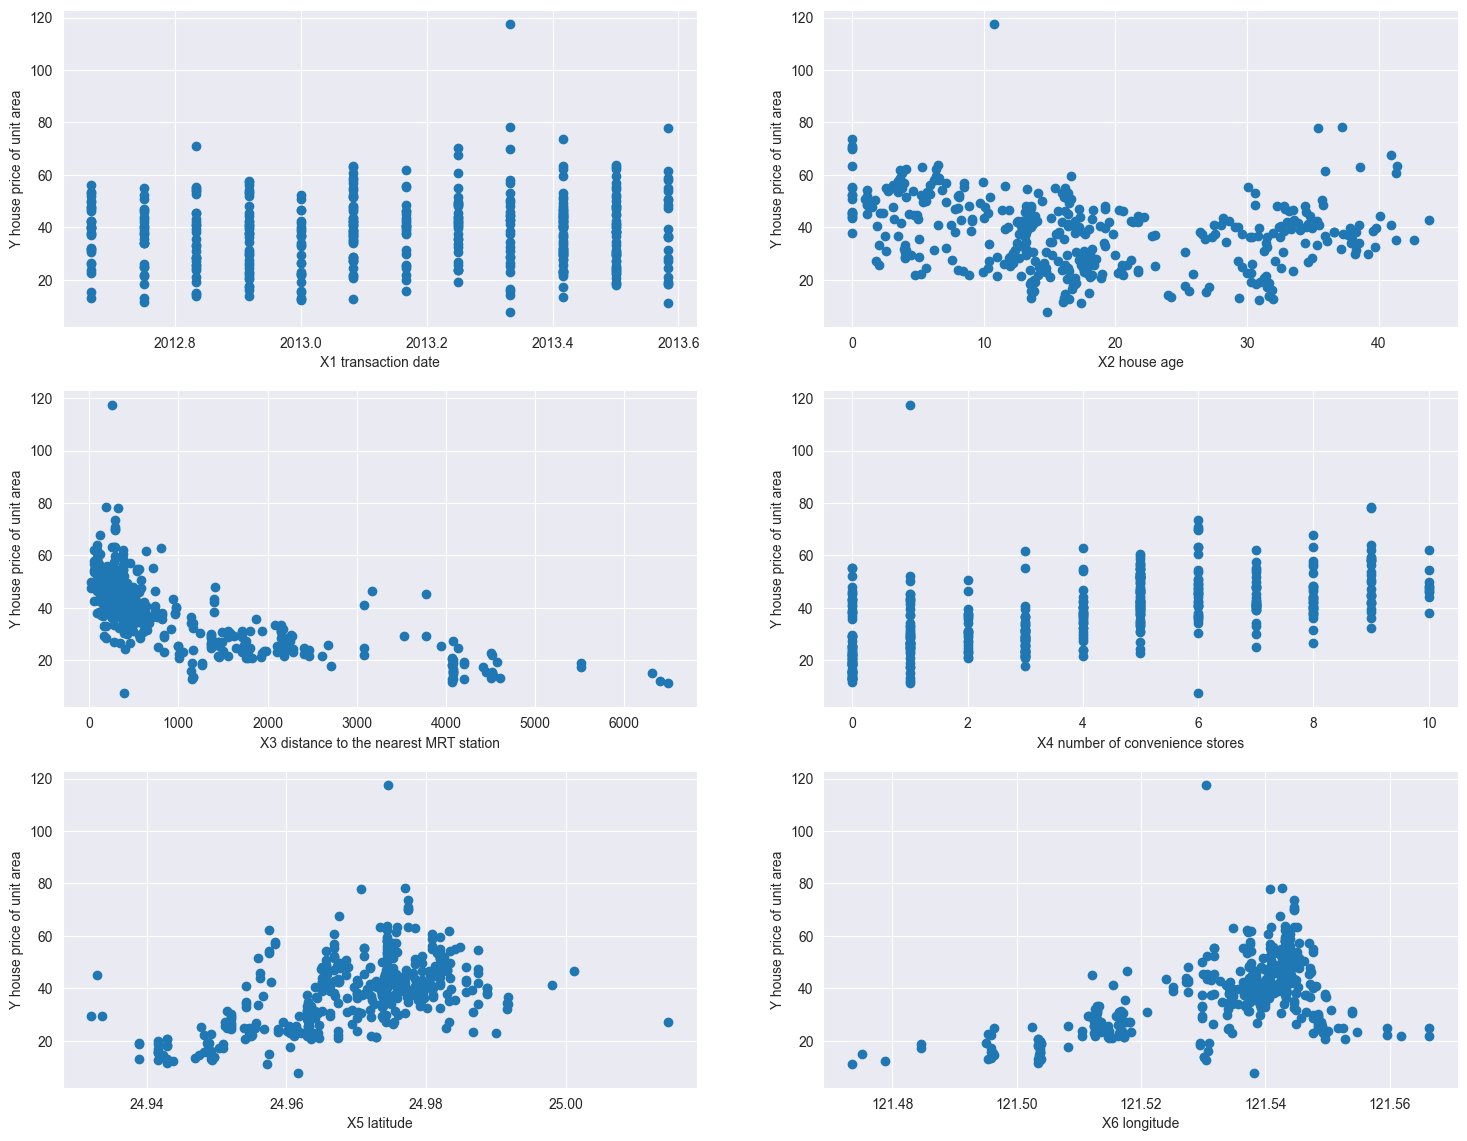

In [66]:
import matplotlib.pyplot as plt

target = 'Y house price of unit area'

plt.figure(figsize=(18, 14))

for i, feature in enumerate(df):
    if not feature == target and not feature == 'No':
        plt.subplot(3, 2, i)
        plt.scatter(df[feature], df[target])
        plt.xlabel(feature)
        plt.ylabel(target)

plt.show()

# Data preparation
The dataset is split into X (features) and Y (target), then a training set will be produced from the original values. The training set will be used to train the model and test it. Because linear and logistic regression use different kinds of values, this step prepares data for both. Linear regression has straightforward features and targets, but logistic regression needs standardized values and compares them as a matrix.

In [67]:
from sklearn.model_selection import train_test_split
df = df.drop(['No'], axis=1)
# Get features and targets of the dataset
X = df.drop(['Y house price of unit area'], axis=1)
y = df['Y house price of unit area']

# Transform target value to binary based on it being more than or less than (or equal to) average price.
# This is for getting X and y values for the logistic regression
price_mean = df['Y house price of unit area'].mean()
df['Y house price of unit area'] = df['Y house price of unit area'].map(lambda v: 1 if v > price_mean else 0).astype('int64')

# Grab X and y values for logistic regression
X_log, y_log = df.iloc[:,:6], df.iloc[:,6]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(331, 6) (83, 6) (331,) (83,)


# Modeling
This dataset will be used to train two different models, a linear regression model and a logistic regression model. 

## Linear regression model

In [68]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred_linear = model.predict(X_test)

In [69]:
# Find intercept and coefficient values
b0 = model.intercept_
b1 = model.coef_[0]
print(f'Intercept: {b0:.2f}, Coefficient: {b1:.4f}')

Intercept: -13319.82, Coefficient: 5.2902


The coefficient is negative in its absolute value, meaning there is a positive relationship between increasing the corresponding variable and the prediction increasing. This is however, not good enough to be conclusive, so further metrics must be gained.
For that, we use mean absolute error (MAE). 

## Logistic regression model
The alternative model uses logistic regression, which is a sigmoid function (s-shaped). It can be visualized like this:

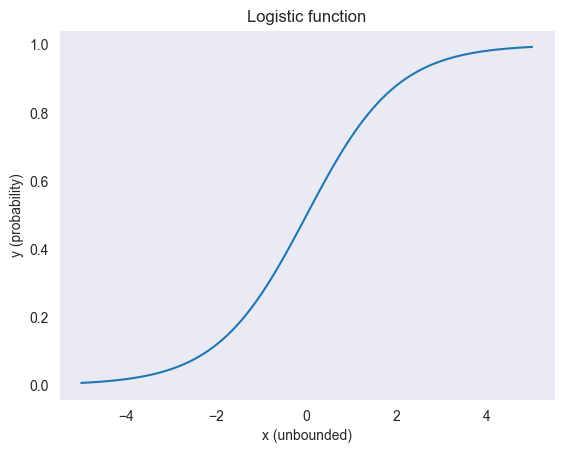

In [70]:
# visualize the sigmoid function
import numpy as np

x = np.linspace(-5, 5, 100)
y = 1 / (1 + np.exp(-x))

plt.plot(x, y)
plt.xlabel('x (unbounded)')
plt.ylabel('y (probability)')
plt.title('Logistic function')
plt.grid()

plt.show()

Logistic regression uses linear regression to predict a continuous value, that is transformed into a probability by using the logistic function pictured above. For the purpose of this algorithm, it will used to convert the Y target into a binary value.
Logistic regression requires the targets to be standardized.

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# standardize the features
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X_log), columns=X_log.columns)
X.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,-0.823683,1.255628,-0.792495,2.007407,1.125430,0.448762
1,-0.823683,0.157086,-0.616612,1.667503,0.912444,0.401139
2,1.541151,-0.387791,-0.414015,0.307885,1.486860,0.688183
3,1.246435,-0.387791,-0.414015,0.307885,1.486860,0.688183
4,-1.121951,-1.117223,-0.549997,0.307885,0.834188,0.592937


In [72]:
# build and fit model
reg = LogisticRegression(solver='lbfgs', max_iter=1000)
reg.fit(X_log, y_log)

print("Coefficients: ",reg.coef_)
print("Intercept: ", reg.intercept_)
print(f"Coefficients mapped to class: {reg.classes_}")

Coefficients:  [[ 0.01610813 -0.05336001 -0.0021926   0.22148557  0.26314272 -0.30536903]]
Intercept:  [-0.00221134]
Coefficients mapped to class: [0 1]


# Evaluation
At a surface level, it can be interpreted that closeness to an MRT station has a significant effect on house price. On average, the smaller the distance to the nearest MRT station, the higher the house price, though there are of course outliers.

## Linear regression
These metrics show that the model is moderately accurate. An R2 score of 0.65 is a bit below the desired result, but is not bad. MAE score of 5.43 means that the model's prediction varies by about 54k Taiwanese dollars from the actual price. This variation is about ~1450€ when converted from Taiwanese dollars.

In [73]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_linear)

print("Mean absolute error (linear regression): %.2f" % mean_absolute_error(y_test, y_pred_linear))
print(f"R2 Score: {r2}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_linear):.2f}")

Mean absolute error (linear regression): 5.47
R2 Score: 0.6481288318236701
MAE: 5.47


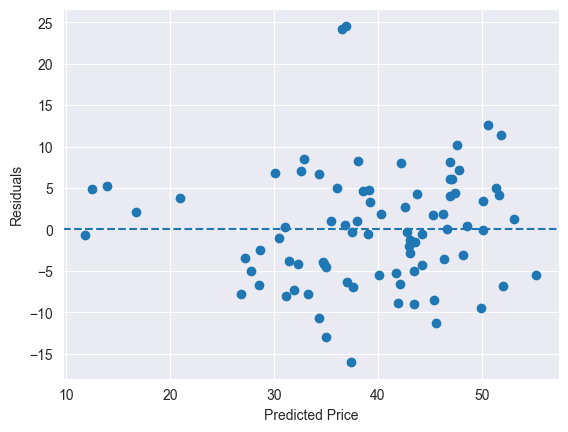

In [74]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_linear

plt.scatter(y_pred_linear, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.show()

## Logistic regression
The logistic regression model got an accuracy score of 0.83 (83%), while its classification report states a precision and recall of 0.83 as well. These are reasonable results, and suggests that the model can be useful for real data.


Accuracy: 0.83
Confusion Matrix:
 [[155  45]
 [ 25 189]]


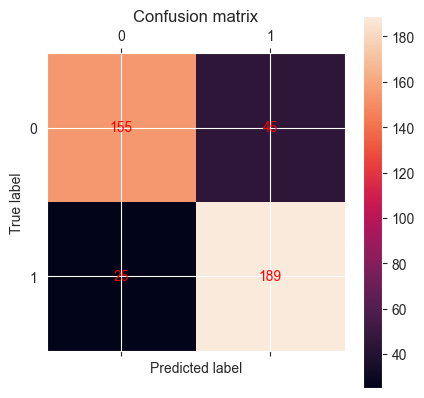

In [75]:
# cross-validation
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score

y_pred_log = cross_val_predict(estimator=reg, X=X_log, y=y_log, cv=10)

cm = confusion_matrix(y_log, y_pred_log)
accuracy = accuracy_score(y_log, y_pred_log)

print("Accuracy: %0.2f" % accuracy)
print("Confusion Matrix:\n", cm)

# visualize confusion matrix
plt.matshow(cm)
plt.title('Confusion matrix')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
# include counts
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red')
plt.show()

In [76]:
from sklearn.metrics import classification_report

# perform a classification report for some final evaluation 
print(classification_report(y_log, y_pred_log))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82       200
           1       0.81      0.88      0.84       214

    accuracy                           0.83       414
   macro avg       0.83      0.83      0.83       414
weighted avg       0.83      0.83      0.83       414


# Deployment
These models could be deployed to predict real estate pricing at a reasonable rate. The linear regression model can be used to predict a numerical price based on parameters such as location, proximity to stores and stations etc. while the logistic regression model can determine if a house is above or below the expected mean price in the area.